Import libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

2. Load the Dataset

In [83]:
fev_source = 'https://raw.githubusercontent.com/GTPB/PSLS20/master/data/fev.txt'

fev = pd.read_csv(fev_source, sep = '\t')

fev.head()

,age,fev,height,gender,smoking
0,9,1.708,57.0,f,0
1,8,1.724,67.5,f,0
2,7,1.720,54.5,f,0
3,9,1.558,53.0,m,0
4,9,1.895,57.0,m,0


3. Data Cleaning & Encoding

In [84]:
fev['gender'] = fev['gender'].map({'f': 0, 'm': 1})  # if sex is stored as 'f'/'m'
fev['smoking'] = fev['smoking'].astype(int)  

In [85]:
fev.head()

,age,fev,height,gender,smoking
0,9,1.708,57.0,0,0
1,8,1.724,67.5,0,0
2,7,1.720,54.5,0,0
3,9,1.558,53.0,1,0
4,9,1.895,57.0,1,0


4. Explore the dataset

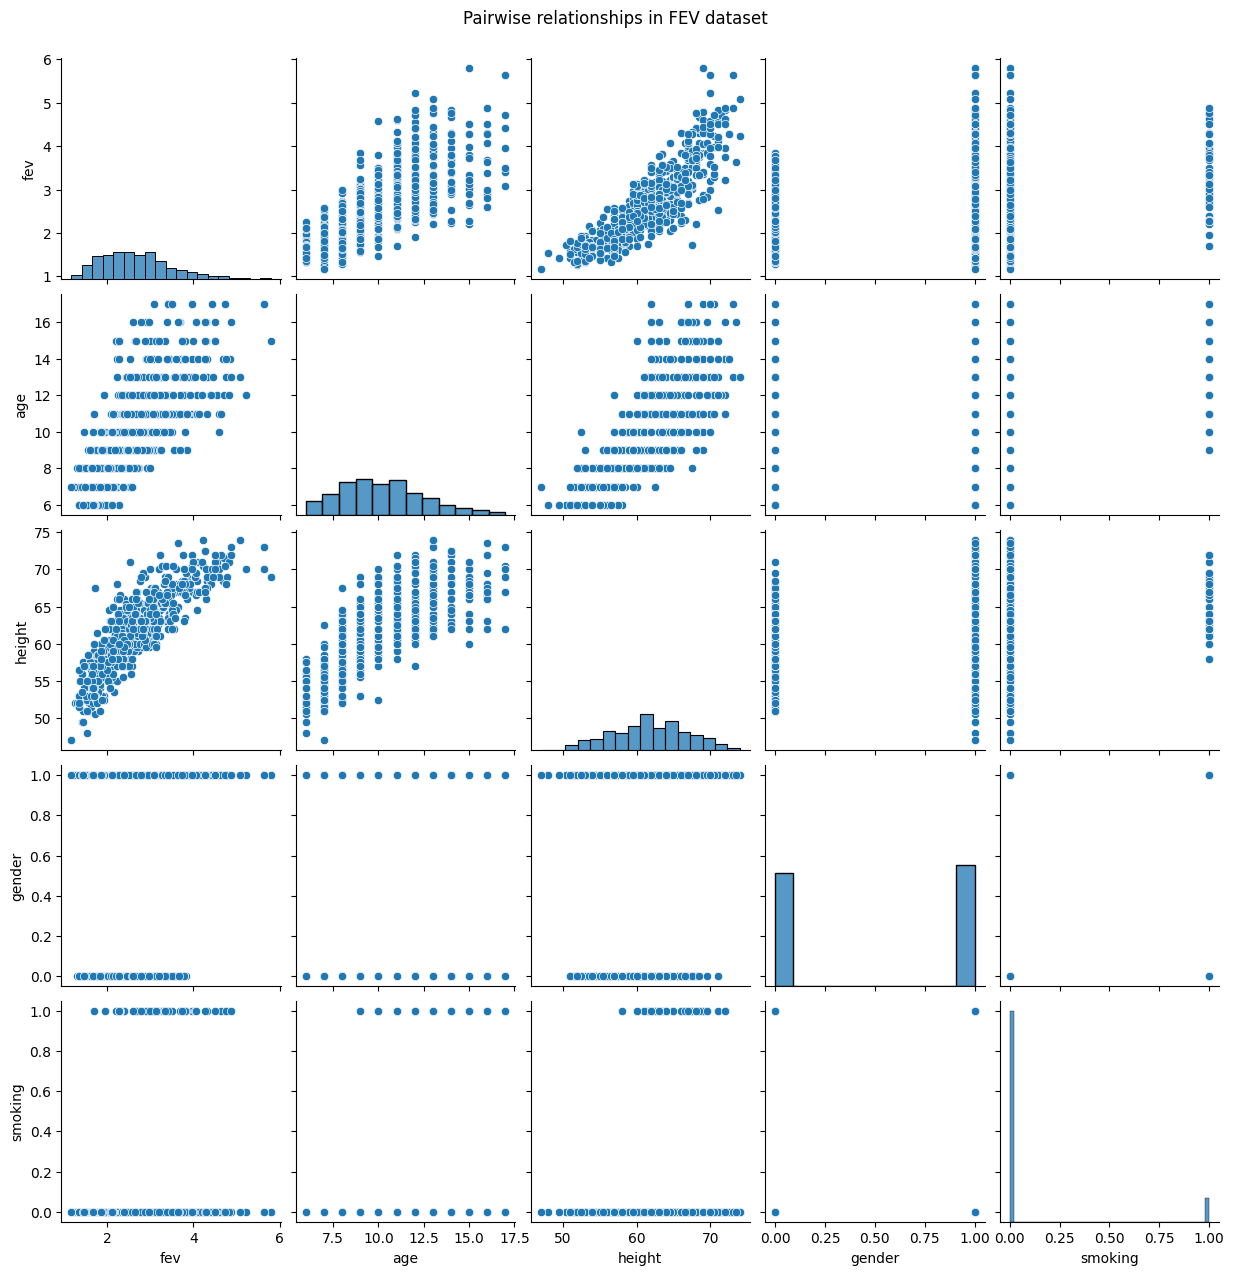

In [86]:
sns.pairplot(fev[['fev','age','height','gender','smoking']])
plt.suptitle("Pairwise relationships in FEV dataset", y=1.02)
plt.show()

In [87]:
# Check for missing or invalid values
print("\nMissing values:\n", fev.isnull().sum())
print("\nBasic stats:\n", fev.describe())


Missing values:
 age        0
fev        0
height     0
gender     0
smoking    0
dtype: int64

Basic stats:
               age         fev      height      gender     smoking
count  606.000000  606.000000  606.000000  606.000000  606.000000
mean    10.145215    2.695568   61.730858    0.518152    0.100660
std      2.551688    0.829505    5.179810    0.500083    0.301127
min      6.000000    1.165000   47.000000    0.000000    0.000000
25%      8.000000    2.091500   58.000000    0.000000    0.000000
50%     10.000000    2.580000   62.000000    1.000000    0.000000
75%     12.000000    3.145500   65.500000    1.000000    0.000000
max     17.000000    5.793000   74.000000    1.000000    1.000000


In [88]:
#class challenge #  Feature Engineering ────────────────────────────────────
fev['height_age_ratio'] = fev['height'] / fev['age']

In [89]:
# Age × Height interaction
fev['age_x_height'] = fev['age'] * fev['height']

In [90]:
print("\n=== Engineered Features ===")
print(fev[['age', 'height', 'height_age_ratio', 'age_x_height']].head())
print("\nheight_age_ratio stats:\n", fev['height_age_ratio'].describe())
print("\nage_x_height stats:\n", fev['age_x_height'].describe())
print("Any NaN in height_age_ratio:", fev['height_age_ratio'].isnull().any())
print("Any NaN in age_x_height    :", fev['age_x_height'].isnull().any())


=== Engineered Features ===
   age  height  height_age_ratio  age_x_height
0    9    57.0          6.333333         513.0
1    8    67.5          8.437500         540.0
2    7    54.5          7.785714         381.5
3    9    53.0          5.888889         477.0
4    9    57.0          6.333333         513.0

height_age_ratio stats:
 count    606.000000
mean       6.371786
std        1.210911
min        3.647059
25%        5.500000
50%        6.316667
75%        7.166667
max        9.666667
Name: height_age_ratio, dtype: float64

age_x_height stats:
 count     606.000000
mean      636.274257
std       201.288104
min       288.000000
25%       480.000000
50%       615.000000
75%       759.000000
max      1241.000000
Name: age_x_height, dtype: float64
Any NaN in height_age_ratio: False
Any NaN in age_x_height    : False


5. Split Train/Test

In [ ]:
X = fev[['age', 'height', 'gender', 'smoking']]

#class challenge
X_red  = fev[['age', 'gender', 'smoking']]
X_eng  = fev[['height_age_ratio', 'age_x_height', 'gender', 'smoking']]
y = fev['fev']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#class challenge #  Model Training and Evaluation ─────────────────────────────
X_train_r, X_test_r, _,       _      = train_test_split(X_red,  y, test_size=0.3, random_state=42)
X_train_e, X_test_e, _,       _      = train_test_split(X_eng,  y, test_size=0.3, random_state=42)

In [78]:
X_train.head()

,age,height,gender,smoking
564,11,65.0,0,1
605,15,66.5,0,0
485,11,67.5,1,0
441,12,64.5,0,0
305,11,61.5,0,0


6: Train the Multivariate Regression Model

In [79]:
model = LinearRegression()
model.fit(X_train, y_train)

#class challenge #  Model Training and Evaluation ─────────────────────────────
model_red  = LinearRegression().fit(X_train_r, y_train)
model_eng  = LinearRegression().fit(X_train_e, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.09, 0.1 , 0.15,-0.17]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['age','height','gender','smoking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.601
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


Inspect the model coefficients

In [80]:
print("Intercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept: -4.601236676113932
age: 0.08695350247792027
height: 0.10294535986715453
gender: 0.14827068216247605
smoking: -0.17458423567225576


Interpretation biologically:

Each coefficient tells how much FEV changes per unit change in that predictor, adjusting for others.
Example: A positive height coefficient means taller children tend to have higher FEV when age, sex, and smoking are held constant.

In [101]:
#class challenge
print("Intercept:", model_red.intercept_)
for feature, coef in zip(X_red.columns, model_red.coef_):
    print(f"  {feature}: {coef}")

Intercept: 0.08666490560185292
  age: 0.24633480710458536
  gender: 0.2893655640100055
  smoking: -0.21800087521247458


In [102]:
#class challenge
print("Intercept:", model_eng.intercept_)
for feature, coef in zip(X_eng.columns, model_eng.coef_):
    print(f"  {feature}: {coef}")

Intercept: -3.1054371974943207
  height_age_ratio: 0.36307145184025336
  age_x_height: 0.005424876750748849
  gender: 0.14287670657978904
  smoking: -0.300340546884506


Evaluate the model

In [105]:
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.7821789359644236
Mean Squared Error: 0.1576525280675643


In [109]:
y_pred_eng = model_eng.predict(X_test_e)

print("R² Score:", r2_score(y_test, y_pred_eng))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_eng))

R² Score: 0.732399941874106
Mean Squared Error: 0.19368111096768803


In [110]:
y_pred_red = model_red.predict(X_test_r)

print("R² Score:", r2_score(y_test, y_pred_red))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_red))


R² Score: 0.5792738814759204
Mean Squared Error: 0.30450928381536835


In [111]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n--- {name} ---")
    print(f"  R²   : {r2:.4f}  → model explains {r2*100:.1f}% of variance in FEV")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f} litres average error")
    return {"Model": name, "R2": round(r2,4), "MSE": round(mse,4), "RMSE": round(rmse,4)}


In [113]:
print("\n=== MODEL EVALUATION (test set) ===")
results = []
results.append(evaluate("Full       (age + height + gender + smoking)",        model, X_test, y_test))
results.append(evaluate("Reduced    (age + gender + smoking)",                 model_red,  X_test_r, y_test))
results.append(evaluate("Engineered (ratio + interaction + gender + smoking)", model_eng,  X_test_e, y_test))


=== MODEL EVALUATION (test set) ===

--- Full       (age + height + gender + smoking) ---
  R²   : 0.7822  → model explains 78.2% of variance in FEV
  MSE  : 0.1577
  RMSE : 0.3971 litres average error

--- Reduced    (age + gender + smoking) ---
  R²   : 0.5793  → model explains 57.9% of variance in FEV
  MSE  : 0.3045
  RMSE : 0.5518 litres average error

--- Engineered (ratio + interaction + gender + smoking) ---
  R²   : 0.7324  → model explains 73.2% of variance in FEV
  MSE  : 0.1937
  RMSE : 0.4401 litres average error


In [114]:
results_df = pd.DataFrame(results)
print("\n=== COMPARISON TABLE ===")
print(results_df.to_string(index=False))


=== COMPARISON TABLE ===
                                              Model     R2    MSE   RMSE
       Full       (age + height + gender + smoking) 0.7822 0.1577 0.3971
                Reduced    (age + gender + smoking) 0.5793 0.3045 0.5518
Engineered (ratio + interaction + gender + smoking) 0.7324 0.1937 0.4401


In [115]:
# Explicitly identify best model
best_model = results_df.loc[results_df['R2'].idxmax()]
worst_model = results_df.loc[results_df['R2'].idxmin()]
print(f"\nBest R²  → {best_model['Model']} ({best_model['R2']})")
print(f"Lowest R² → {worst_model['Model']} ({worst_model['R2']})")



Best R²  → Full       (age + height + gender + smoking) (0.7822)
Lowest R² → Reduced    (age + gender + smoking) (0.5793)


In [116]:
# ── 8. Simplicity vs Performance ─────────────────────────────
r2_full = results_df.loc[results_df['Model'].str.startswith('Full'), 'R2'].values[0]
r2_red  = results_df.loc[results_df['Model'].str.startswith('Reduced'), 'R2'].values[0]
r2_eng  = results_df.loc[results_df['Model'].str.startswith('Engineered'), 'R2'].values[0]
 
r2_diff_full_red = round(r2_full - r2_red, 4)
r2_diff_eng_full = round(r2_eng - r2_full, 4)

In [117]:
print(f"""
=== SIMPLICITY vs PERFORMANCE ===
 
Full vs Reduced  : removing height drops R² by {r2_diff_full_red} — a meaningful loss
Engineered vs Full: adding combined features gains only {r2_diff_eng_full} in R²

The Reduced model (3 features) is simpler but loses too much accuracy
by dropping height. It is not a good trade-off.
 
The Engineered model may score slightly higher but uses derived features
(ratios and interactions) that are harder to interpret than raw values.
It is not simpler than the Full model — just different.
 
Best balance → FULL MODEL
  - Strong R² with the fewest, most interpretable features
  - Every coefficient (age, height, gender, smoking) has a direct
    real-world meaning a non-expert can understand
  - The tiny R² gain from the Engineered model does not justify
    replacing transparent variables with derived ones
""")


=== SIMPLICITY vs PERFORMANCE ===

Full vs Reduced  : removing height drops R² by 0.2029 — a meaningful loss
Engineered vs Full: adding combined features gains only -0.0498 in R²

The Reduced model (3 features) is simpler but loses too much accuracy
by dropping height. It is not a good trade-off.

The Engineered model may score slightly higher but uses derived features
(ratios and interactions) that are harder to interpret than raw values.
It is not simpler than the Full model — just different.

Best balance → FULL MODEL
  - Strong R² with the fewest, most interpretable features
  - Every coefficient (age, height, gender, smoking) has a direct
    real-world meaning a non-expert can understand
  - The tiny R² gain from the Engineered model does not justify
    replacing transparent variables with derived ones



In [118]:
# ── 9. Biological Interpretation ─────────────────────────────
print("""
=== BIOLOGICAL INTERPRETATION ===
 
Height-to-Age ratio (height / age):
  Two children can share the same height but be different ages.
  The older child has had more years for chest and lung development.
  Dividing height by age captures proportional body maturity —
  a better biological proxy for lung capacity than height alone.
 
Age × Height interaction:
  During puberty, taller children also experience faster lung
  development — age and height amplify each other. A model that
  treats age and height as independent misses this joint effect.
  Multiplying them encodes that biological acceleration directly.
 
Combined, these features reflect that lung volume is driven by
chest cavity size — shaped by BOTH physical stature and biological
maturity, not either factor in isolation. Growth and lung capacity
are not linear or independent, which is exactly why the interaction
term adds value beyond using age and height separately.
""")


=== BIOLOGICAL INTERPRETATION ===

Height-to-Age ratio (height / age):
  Two children can share the same height but be different ages.
  The older child has had more years for chest and lung development.
  Dividing height by age captures proportional body maturity —
  a better biological proxy for lung capacity than height alone.

Age × Height interaction:
  During puberty, taller children also experience faster lung
  development — age and height amplify each other. A model that
  treats age and height as independent misses this joint effect.
  Multiplying them encodes that biological acceleration directly.

Combined, these features reflect that lung volume is driven by
chest cavity size — shaped by BOTH physical stature and biological
maturity, not either factor in isolation. Growth and lung capacity
are not linear or independent, which is exactly why the interaction
term adds value beyond using age and height separately.

